In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install Ultralytics
!pip install ultralytics -q

# Verify GPU
!nvidia-smi

# Import and check
from ultralytics import YOLO
import torch
print(torch.cuda.is_available())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.6 MB/s eta 0:00:00
Mon May 11 20:57:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8         

In [ ]:
# Symlink dataset from Drive for convenience
import os
DATASET_PATH = "/content/drive/MyDrive/multiclass/dataset"  # your path
!ls {DATASET_PATH}

data.yaml  test  train	val


In [ ]:
SHARED_PARAMS = dict(
    data   = f"{DATASET_PATH}/data.yaml",
    imgsz  = 640,
    epochs = 200,          # between 100–500
    batch  = 16,
    patience = 30,         # early stopping — required!
    lr0    = 0.01,
    lrf    = 0.01,
    momentum = 0.937,
    weight_decay = 0.0005,
    # Data augmentation
    hsv_h  = 0.015,
    hsv_s  = 0.7,
    hsv_v  = 0.4,
    flipud = 0.0,
    fliplr = 0.5,
    mosaic = 1.0,
    mixup  = 0.1,
    plots  = True,
)

In [ ]:
model1 = YOLO("yolov8n.pt")
model1.train(optimizer="auto", name="nano_auto", **SHARED_PARAMS)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/multiclass/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=nano_auto, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77fc23fe3b90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
!cp -r /content/runs/detect/nano_auto /content/drive/MyDrive/multiclass/yolo_results/

In [ ]:
model2 = YOLO("yolov8n.pt")
model2.train(optimizer="SGD", name="nano_sgd", **SHARED_PARAMS)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/multiclass/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=nano_sgd, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77fb9534c620>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
!cp -r /content/runs/detect/nano_sdg /content/drive/MyDrive/multiclass/yolo_results/

cp: cannot stat '/content/runs/detect/nano_sdg': No such file or directory


In [ ]:
model3 = YOLO("yolov8n.pt")
model3.train(optimizer="Adam", name="nano_adam", **SHARED_PARAMS)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/multiclass/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=nano_adam, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77fb940f8a40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
!cp -r /content/runs/detect/nano_adam /content/drive/MyDrive/multiclass/yolo_results/

In [ ]:
!cp -r /content/runs/detect/nano_sgd /content/drive/MyDrive/multiclass/yolo_results/

In [ ]:
for run_name in ["nano_auto", "nano_sgd", "nano_adam"]:
    model = YOLO(f"/content/runs/detect/{run_name}/weights/best.pt")
    metrics = model.val(data=f"{DATASET_PATH}/data.yaml", split="test")
    print(f"\n--- {run_name} ---")
    print(f"mAP50: {metrics.box.map50:.4f}")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"Precision: {metrics.box.mp:.4f}")
    print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.2 ms, read: 0.1±0.1 MB/s, size: 47.8 KB)
val: Scanning /content/drive/MyDrive/multiclass/dataset/test/labels... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 1.3it/s 11.5s
val: New cache created: /content/drive/MyDrive/multiclass/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.2it/s 0.4s
                   all         15         56      0.796      0.798      0.851      0.486
            headphones          3          3      0.564          1      0.995      0.548
              keyboard         11         12       0.87      0.667      0.779       0.41
                laptop         13         16      0.759      0.875      0.866      0.571
               monitor         12         12   

In [ ]:
!cp -r /content/runs/detect/nano_auto /content/drive/MyDrive/multiclass/yolo_results/

In [ ]:
model_s = YOLO("yolov8s.pt")
model_s.train(optimizer="AdamW", name="small_adamw", **SHARED_PARAMS)
!cp -r /content/runs/detect/small_adamw /content/drive/MyDrive/multiclass/yolo_results/

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/multiclass/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=small_adamw, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, ov

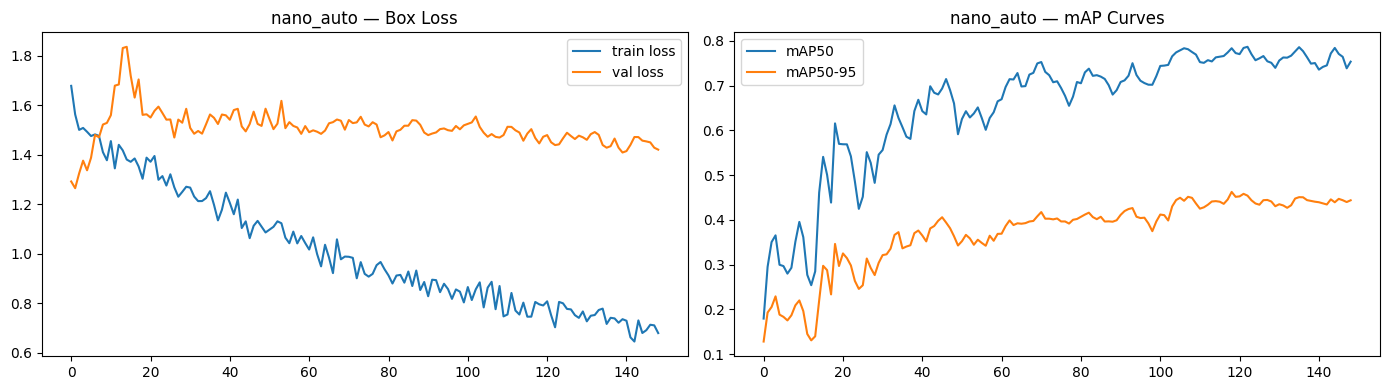

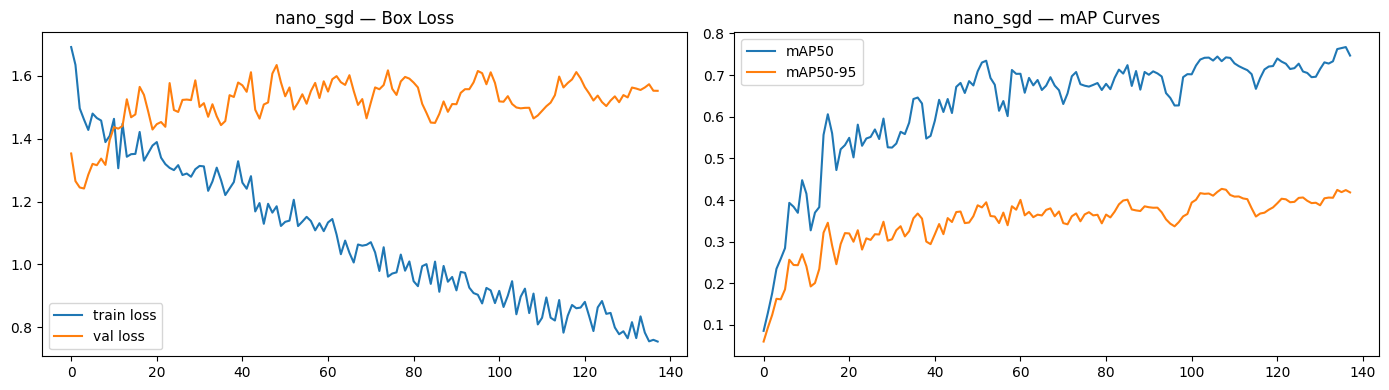

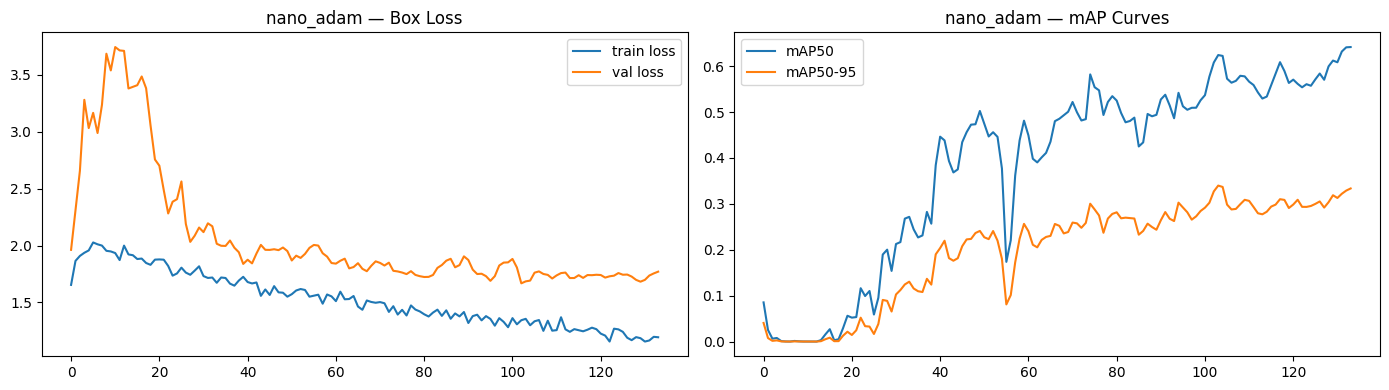

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

for run_name in ["nano_auto", "nano_sgd", "nano_adam"]:
    df = pd.read_csv(f"/content/runs/detect/{run_name}/results.csv")
    df.columns = df.columns.str.strip()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(df["train/box_loss"], label="train loss")
    axes[0].plot(df["val/box_loss"],   label="val loss")
    axes[0].set_title(f"{run_name} — Box Loss")
    axes[0].legend()
    axes[1].plot(df["metrics/mAP50(B)"], label="mAP50")
    axes[1].plot(df["metrics/mAP50-95(B)"], label="mAP50-95")
    axes[1].set_title(f"{run_name} — mAP Curves")
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive//yolo_results/{run_name}_curves.png")
    plt.show()

In [ ]:
model_n = YOLO("/content/runs/detect/nano_auto/weights/best.pt")
model_s = YOLO("/content/runs/detect/small_adamw/weights/best.pt")
for name, m in [("YOLOv8-n", model_n), ("YOLOv8-s", model_s)]:
    metrics = m.val(data=f"{DATASET_PATH}/data.yaml", split="test")
    print(f"\n{name} per-class AP:")
    for i, cls in enumerate(metrics.names.values()):
        print(f"  {cls}: {metrics.box.ap[i]:.4f}")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 29.8±7.0 MB/s, size: 51.7 KB)
val: Scanning /content/drive/MyDrive/multiclass/dataset/test/labels.cache... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 4.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.9it/s 0.5s
                   all         15         56      0.796      0.798      0.851      0.486
            headphones          3          3      0.564          1      0.995      0.548
              keyboard         11         12       0.87      0.667      0.779       0.41
                laptop         13         16      0.759      0.875      0.866      0.571
               monitor         12         12      0.904      0.833       0.87      0.554
                 mouse         12  

In [ ]:
import pandas as pd

df = pd.read_csv("/content/runs/detect/small_adamw/results.csv")
df.columns = df.columns.str.strip()
print(df[["epoch", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]].tail(20))
print(f"\nBest mAP50-95: {df['metrics/mAP50-95(B)'].max():.4f} at epoch {df['metrics/mAP50-95(B)'].idxmax()+1}")
print(f"Total epochs trained: {len(df)}")

    epoch  metrics/mAP50(B)  metrics/mAP50-95(B)
11     12           0.00000              0.00000
12     13           0.00000              0.00000
13     14           0.00000              0.00000
14     15           0.00000              0.00000
15     16           0.00000              0.00000
16     17           0.00000              0.00000
17     18           0.00000              0.00000
18     19           0.00000              0.00000
19     20           0.00001              0.00000
20     21           0.00005              0.00001
21     22           0.00938              0.00636
22     23           0.01447              0.00705
23     24           0.05072              0.01884
24     25           0.09811              0.03905
25     26           0.11048              0.04207
26     27           0.11908              0.04605
27     28           0.15296              0.05868
28     29           0.22414              0.09592
29     30           0.20556              0.07284
30     31           

In [ ]:
SHARED_PARAMS_S = {**SHARED_PARAMS, "patience": 50}  # override just patience

model_s = YOLO("yolov8s.pt")
model_s.train(optimizer="AdamW", name="small_adamw_v2", **SHARED_PARAMS_S)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/multiclass/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=small_adamw_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77fc23fa8a40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
!cp -r /content/runs/detect/small_adamw_v2 /content/drive/MyDrive/multiclass/yolo_results/

In [ ]:
!cp -r /content/runs /content/drive/MyDrive/multiclass/session_backup/

In [ ]:
!pip install streamlit pyngrok ultralytics pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 116.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 131.5 MB/s eta 0:00:00


In [ ]:
!pip install streamlit ultralytics pillow -q
!npm install -g localtunnel -q

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
# Cell 3 — Get your tunnel password FIRST, then start Streamlit in background
import urllib.request
ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
print(f"🔑 Your tunnel password: {ip}")

# --server.address=localhost is the critical fix
!streamlit run /content/app.py --server.address=localhost --server.port=8501 &>/content/logs.txt &

🔑 Your tunnel password: 35.186.158.147


In [ ]:
# Cell 4 — Open the tunnel (this cell stays running — that's normal)
!npx localtunnel --port 8501

⠙⠹⠸⠼your url is: https://shiny-roses-attend.loca.lt
^C


In [ ]:
!cat /content/logs.txt



2026-05-12 10:10:57.987 Port 8501 is not available
